<a href="https://colab.research.google.com/github/M-Amine-HM/Alzheimer-MRI-Classification-VGG16/blob/main/Alzheimer%E2%80%99s_Disease_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Alzheimer’s Disease Classification from Brain MRI**

**Download the Kaggle Dataset using api key**

In [ ]:
!pip install opendatasets
!pip install pandas

In [ ]:
import os
from google.colab import userdata

# Securely set environment variables for Kaggle API
# Go to the 'Key' icon on the left of Colab and add 'KAGGLE_USERNAME' and 'KAGGLE_KEY'
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

import opendatasets as od
# Now it will download without prompting you in the output
od.download("https://www.kaggle.com/datasets/marcopinamonti/alzheimer-mri-4-classes-dataset")

In [ ]:
# Install required libraries (if not already installed)
!pip install tensorflow keras scikit-learn matplotlib seaborn opencv-python pillow -q

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import warnings
warnings.filterwarnings('ignore')

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow. keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0

# Sklearn libraries
from sklearn. model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight

# Set random seeds for reproducibility
np.random. seed(42)
tf.random.set_seed(42)

print("="*70)
print("ENVIRONMENT SETUP COMPLETE")
print("="*70)
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Define dataset path
base_path = '/content/alzheimer-mri-4-classes-dataset/Alzheimer_MRI_4_classes_dataset'

# Verify dataset structure
print("\n" + "="*70)
print("DATASET VERIFICATION")
print("="*70)

if os.path.exists(base_path):
    print(f"✓ Dataset path found: {base_path}")

    # List all folders (classes)
    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    classes = sorted(classes)

    print(f"\n✓ Number of classes found: {len(classes)}")
    print(f"✓ Class names: {classes}")

    print("\n" + "-"*70)
    print("Images per class:")
    print("-"*70)

    total_images = 0
    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        image_files = [f for f in os. listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        num_images = len(image_files)
        total_images += num_images
        print(f"{class_name:20s}:{num_images:5d}images")

    print("-"*70)
    print(f"{'TOTAL':20s}:{total_images:5d}images")
    print("="*70)

else:
    print(f"❌ ERROR: Dataset path not found:  {base_path}")
    print("Please check the path and try again.")

ENVIRONMENT SETUP COMPLETE
TensorFlow Version: 2.19.0
GPU Available: True

DATASET VERIFICATION
✓ Dataset path found: /content/alzheimer-mri-4-classes-dataset/Alzheimer_MRI_4_classes_dataset

✓ Number of classes found: 4
✓ Class names: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

----------------------------------------------------------------------
Images per class:
----------------------------------------------------------------------
MildDemented        :  896images
ModerateDemented    :   64images
NonDemented         : 3200images
VeryMildDemented    : 2240images
----------------------------------------------------------------------
TOTAL               : 6400images


**Cell 2: Visualize Class Distribution and Sample Images**

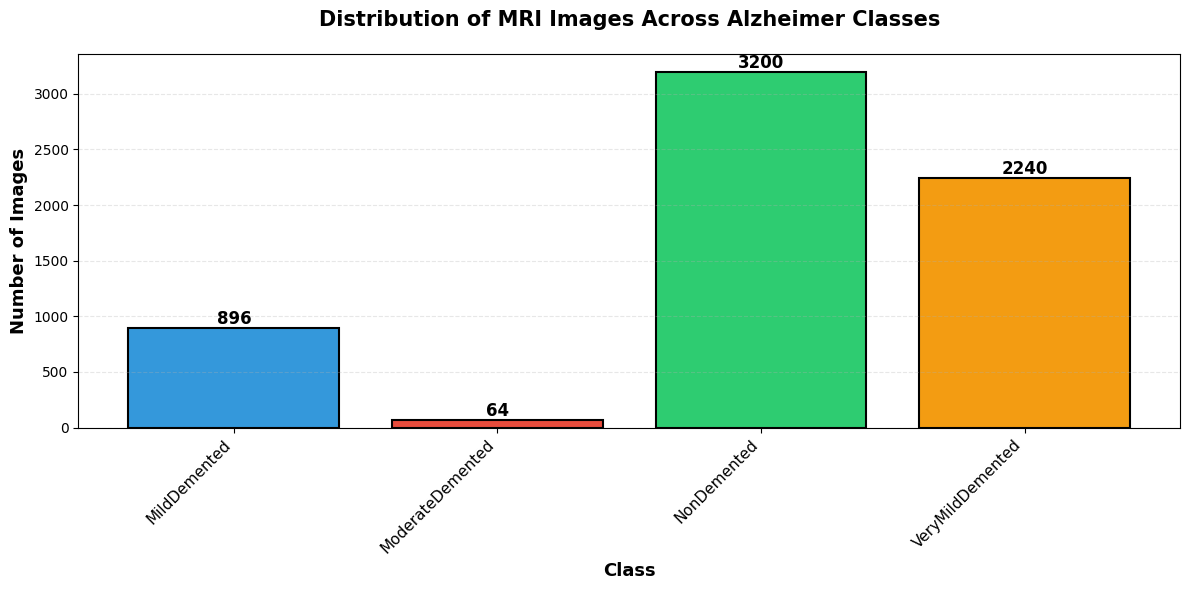


CLASS IMBALANCE ANALYSIS
Maximum class size: 3200
Minimum class size: 64
Imbalance Ratio: 50.00: 1

DISPLAYING SAMPLE IMAGES FROM EACH CLASS


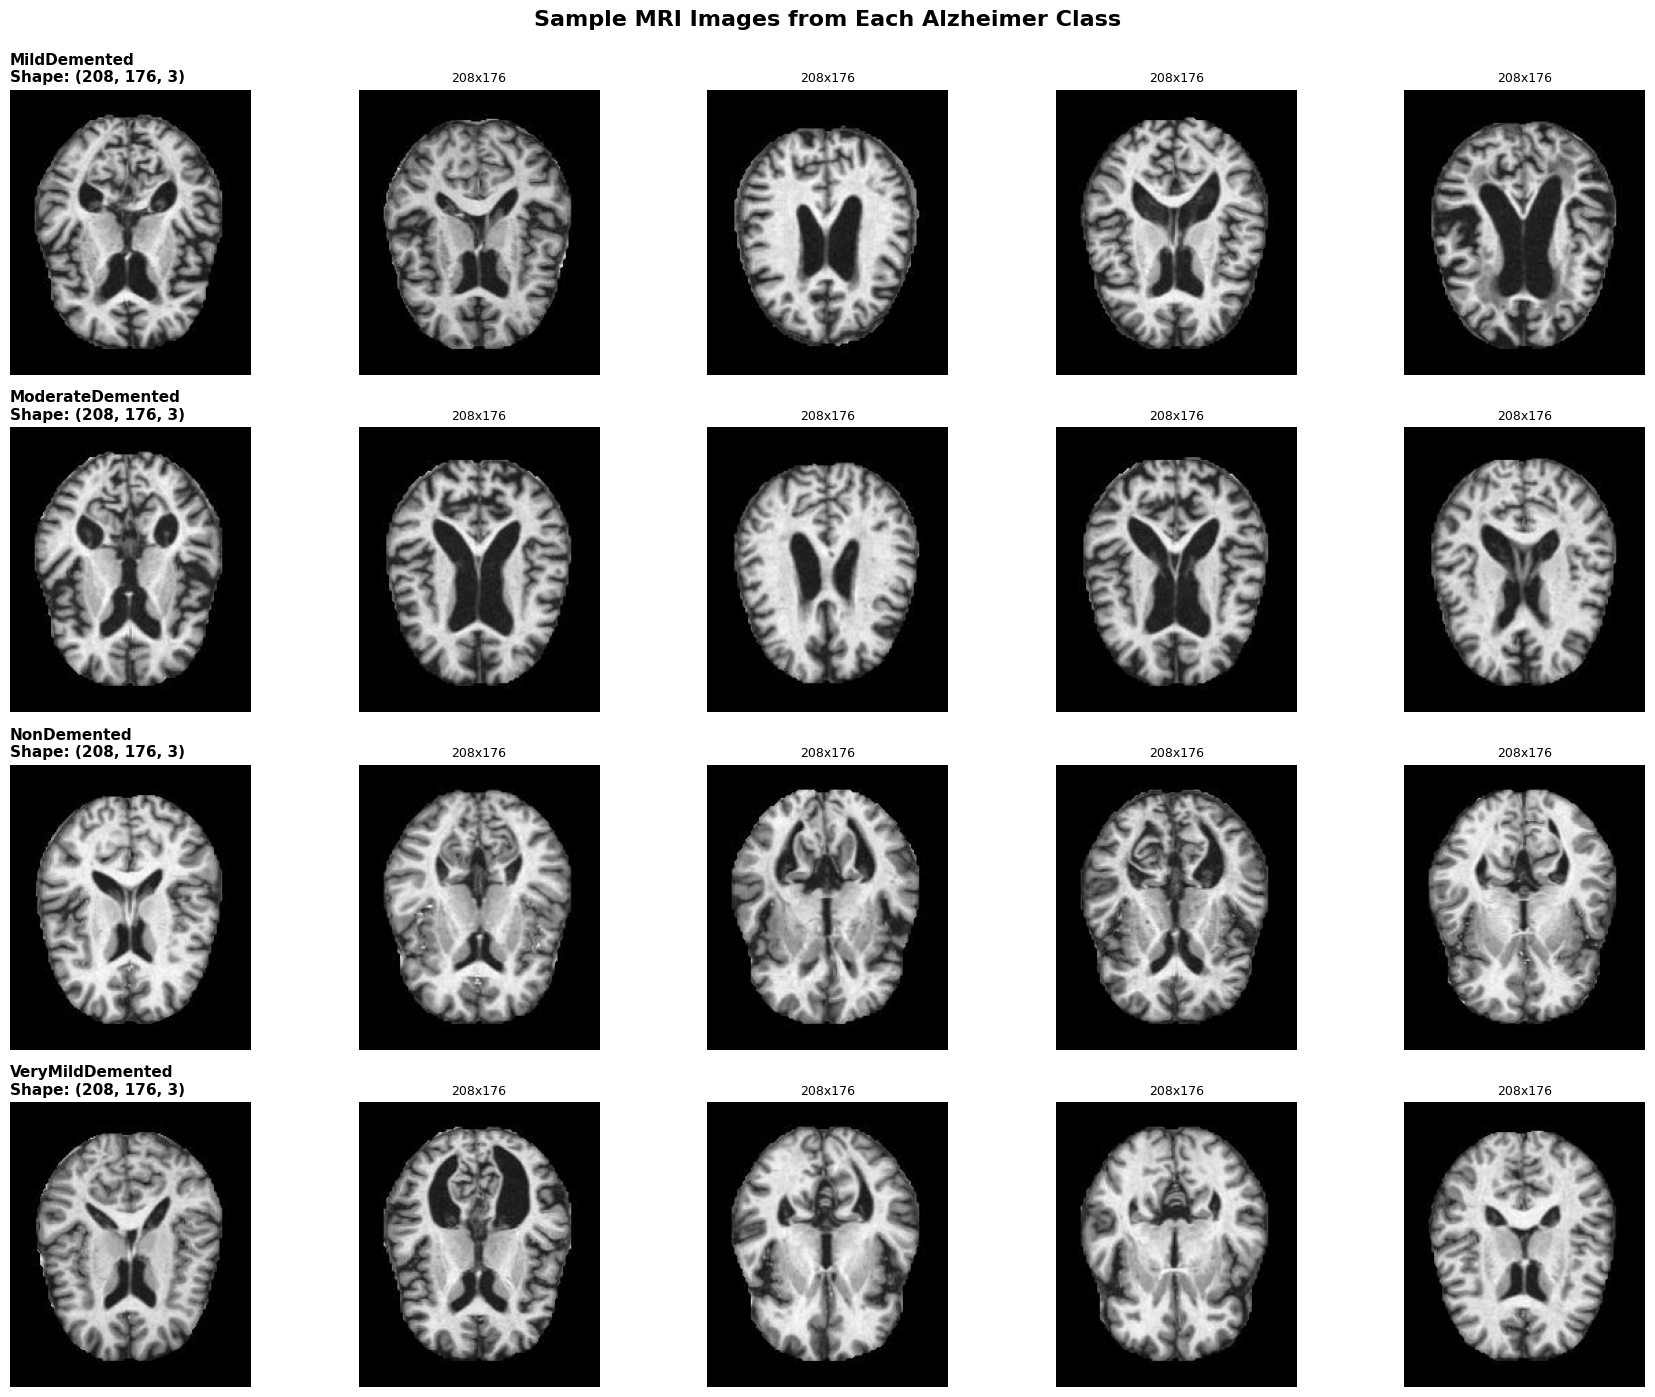


✓ Sample images displayed successfully!


In [ ]:
# Count images per class and create visualization
class_counts = {}
for class_name in classes:
    class_path = os.path. join(base_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[class_name] = len(image_files)

# Visualize class distribution
plt.figure(figsize=(12, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', linewidth=1.5)

plt.xlabel('Class', fontsize=13, fontweight='bold')
plt.ylabel('Number of Images', fontsize=13, fontweight='bold')
plt.title('Distribution of MRI Images Across Alzheimer Classes', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar. get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Check for class imbalance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count

print("\n" + "="*70)
print("CLASS IMBALANCE ANALYSIS")
print("="*70)
print(f"Maximum class size: {max_count}")
print(f"Minimum class size: {min_count}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}: 1")


# Display sample images from each class
print("\n" + "="*70)
print("DISPLAYING SAMPLE IMAGES FROM EACH CLASS")
print("="*70)

fig, axes = plt.subplots(len(classes), 5, figsize=(18, len(classes)*3.5))

for i, class_name in enumerate(classes):
    class_path = os.path.join(base_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]

    for j, img_name in enumerate(image_files):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i, j].imshow(img)
        axes[i, j].axis('off')

        if j == 0:
            axes[i, j].set_title(f'{class_name}\nShape: {img.shape}',
                                fontsize=11, fontweight='bold', loc='left')
        else:
            axes[i, j].set_title(f'{img. shape[0]}x{img. shape[1]}', fontsize=9)

plt.suptitle('Sample MRI Images from Each Alzheimer Class',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Sample images displayed successfully!")

**Cell 3: Prepare Data - Create DataFrame with File Paths and Labels**

In [ ]:
# Create lists to store file paths and labels
file_paths = []
labels = []

print("="*70)
print("CREATING DATASET DATAFRAME")
print("="*70)

# Collect all image paths and their corresponding labels
for class_name in classes:
    class_path = os.path.join(base_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '. png'))]

    for img_name in image_files:
        file_paths.append(os.path.join(class_path, img_name))
        labels.append(class_name)

    print(f"✓ Loaded {len(image_files)} images from {class_name}")

# Create a DataFrame
df = pd.DataFrame({
    'filepath': file_paths,
    'label': labels
})

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n" + "="*70)
print("DATAFRAME SUMMARY")
print("="*70)
print(f"Total samples: {len(df)}")
print(f"\nFirst 10 rows:")
print(df.head(10))

print("\n" + "-"*70)
print("Class distribution in DataFrame:")
print("-"*70)
print(df['label'].value_counts().sort_index())

# Encode labels to numeric values (0, 1, 2, 3)
label_mapping = {label: idx for idx, label in enumerate(sorted(classes))}
df['label_encoded'] = df['label'].map(label_mapping)

print("\n" + "="*70)
print("LABEL ENCODING")
print("="*70)
for label, idx in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"{label:25s}->{idx}")

# Save label mapping for later use
import json
with open('/content/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=4)

print("\n✓ Label mapping saved to:  /content/label_mapping.json")

# Display sample of encoded data
print("\n" + "="*70)
print("SAMPLE OF ENCODED DATA")
print("="*70)
print(df[['label', 'label_encoded']].head(15))

print("\n✓ DataFrame created and shuffled successfully!")
print(f"✓ Shape: {df.shape}")

CREATING DATASET DATAFRAME
✓ Loaded 896 images from MildDemented
✓ Loaded 64 images from ModerateDemented
✓ Loaded 3200 images from NonDemented
✓ Loaded 2240 images from VeryMildDemented

DATAFRAME SUMMARY
Total samples: 6400

First 10 rows:
                                            filepath             label
0  /content/alzheimer-mri-4-classes-dataset/Alzhe...       NonDemented
1  /content/alzheimer-mri-4-classes-dataset/Alzhe...       NonDemented
2  /content/alzheimer-mri-4-classes-dataset/Alzhe...  VeryMildDemented
3  /content/alzheimer-mri-4-classes-dataset/Alzhe...  VeryMildDemented
4  /content/alzheimer-mri-4-classes-dataset/Alzhe...      MildDemented
5  /content/alzheimer-mri-4-classes-dataset/Alzhe...       NonDemented
6  /content/alzheimer-mri-4-classes-dataset/Alzhe...  VeryMildDemented
7  /content/alzheimer-mri-4-classes-dataset/Alzhe...       NonDemented
8  /content/alzheimer-mri-4-classes-dataset/Alzhe...       NonDemented
9  /content/alzheimer-mri-4-classes-dataset/Alzh

**Cell 4: Split Data into Train, Validation, and Test Sets**

SPLITTING DATASET
Training set:     4480 samples (70.0%)
Validation set:   960 samples (15.0%)
Test set:         960 samples (15.0%)
Total:            6400 samples

CLASS DISTRIBUTION IN EACH SPLIT

Training Set (4480 samples):
----------------------------------------
MildDemented             : 627(14.00%)
ModerateDemented         :  45( 1.00%)
NonDemented              :2240(50.00%)
VeryMildDemented         :1568(35.00%)

Validation Set (960 samples):
----------------------------------------
MildDemented             : 134(13.96%)
ModerateDemented         :  10( 1.04%)
NonDemented              : 480(50.00%)
VeryMildDemented         : 336(35.00%)

Test Set (960 samples):
----------------------------------------
MildDemented             : 135(14.06%)
ModerateDemented         :   9( 0.94%)
NonDemented              : 480(50.00%)
VeryMildDemented         : 336(35.00%)


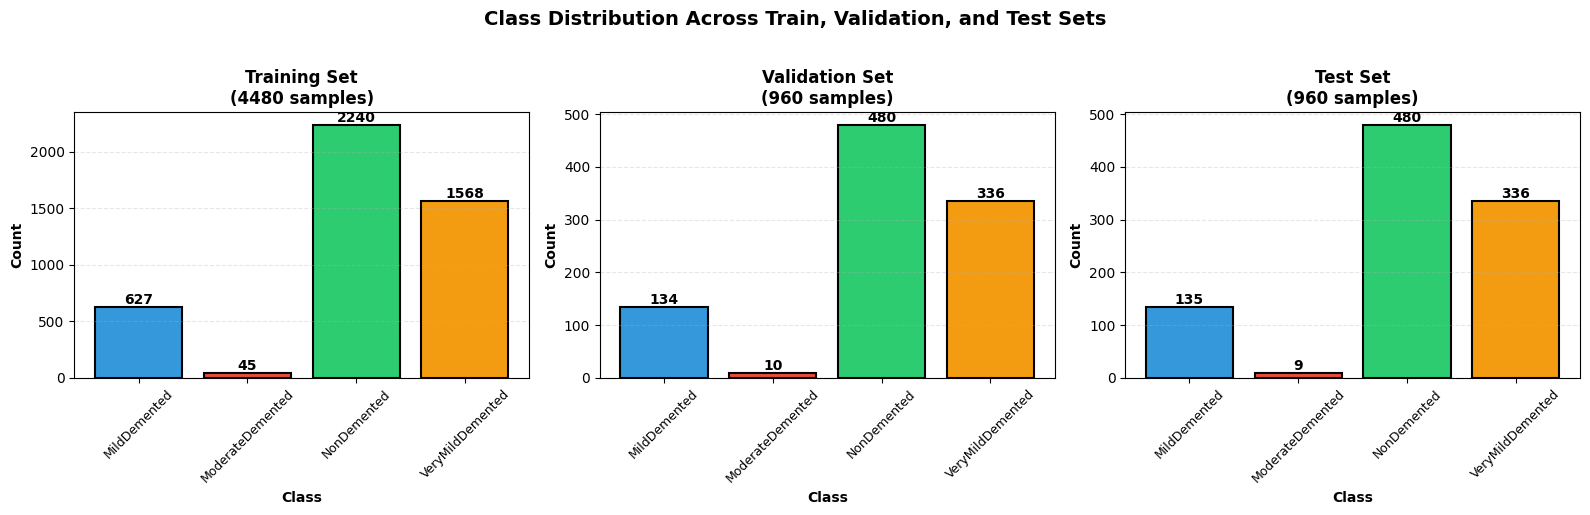


✓ Data split completed successfully!
✓ Stratified sampling ensures balanced class distribution


In [ ]:
# Split data: 70% train, 15% validation, 15% test
print("="*70)
print("SPLITTING DATASET")
print("="*70)

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label_encoded'],
    random_state=42
)

# Second split: Split temp into 50-50 for validation and test (15% each of total)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label_encoded'],
    random_state=42
)

print(f"Training set:    {len(train_df):5d} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation set: {len(val_df):5d} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test set:       {len(test_df):5d} samples ({len(test_df)/len(df)*100:.1f}%)")
print(f"{'Total:':<16s} {len(df):5d} samples")

# Verify class distribution in each split
print("\n" + "="*70)
print("CLASS DISTRIBUTION IN EACH SPLIT")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

splits = [
    ('Training', train_df),
    ('Validation', val_df),
    ('Test', test_df)
]

for idx, (split_name, split_df) in enumerate(splits):
    dist = split_df['label']. value_counts().sort_index()

    print(f"\n{split_name} Set ({len(split_df)} samples):")
    print("-" * 40)
    for class_name, count in dist.items():
        percentage = (count / len(split_df)) * 100
        print(f"{class_name:25s}:{count:4d}({percentage:5.2f}%)")

    # Plot
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    bars = axes[idx].bar(dist.index, dist.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{split_name} Set\n({len(split_df)} samples)',
                        fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Class', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=10, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height)}',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Class Distribution Across Train, Validation, and Test Sets',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Reset indices
train_df = train_df. reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n" + "="*70)
print("✓ Data split completed successfully!")
print("✓ Stratified sampling ensures balanced class distribution")
print("="*70)

**Cell 5: Configure Image Data Generators with Augmentation**

CONFIGURING DATA GENERATORS
Image size: 128x128
Batch size: 32
Number of classes: 4

----------------------------------------------------------------------
Training Data Augmentation:
----------------------------------------------------------------------
  ✓ Rescaling (normalize to 0-1)
  ✓ Rotation (±15 degrees)
  ✓ Width shift (±10%)
  ✓ Height shift (±10%)
  ✓ Shear transformation (10%)
  ✓ Zoom (±10%)
  ✓ Horizontal flip

Validation & Test Data:
----------------------------------------------------------------------
  ✓ Rescaling only (normalize to 0-1)
  ✗ No augmentation

CREATING DATA GENERATORS
Found 4480 validated image filenames belonging to 4 classes.
Found 960 validated image filenames belonging to 4 classes.
Found 960 validated image filenames belonging to 4 classes.

✓ Training batches:    140
✓ Validation batches: 30
✓ Test batches:       30

VISUALIZING AUGMENTED TRAINING IMAGES


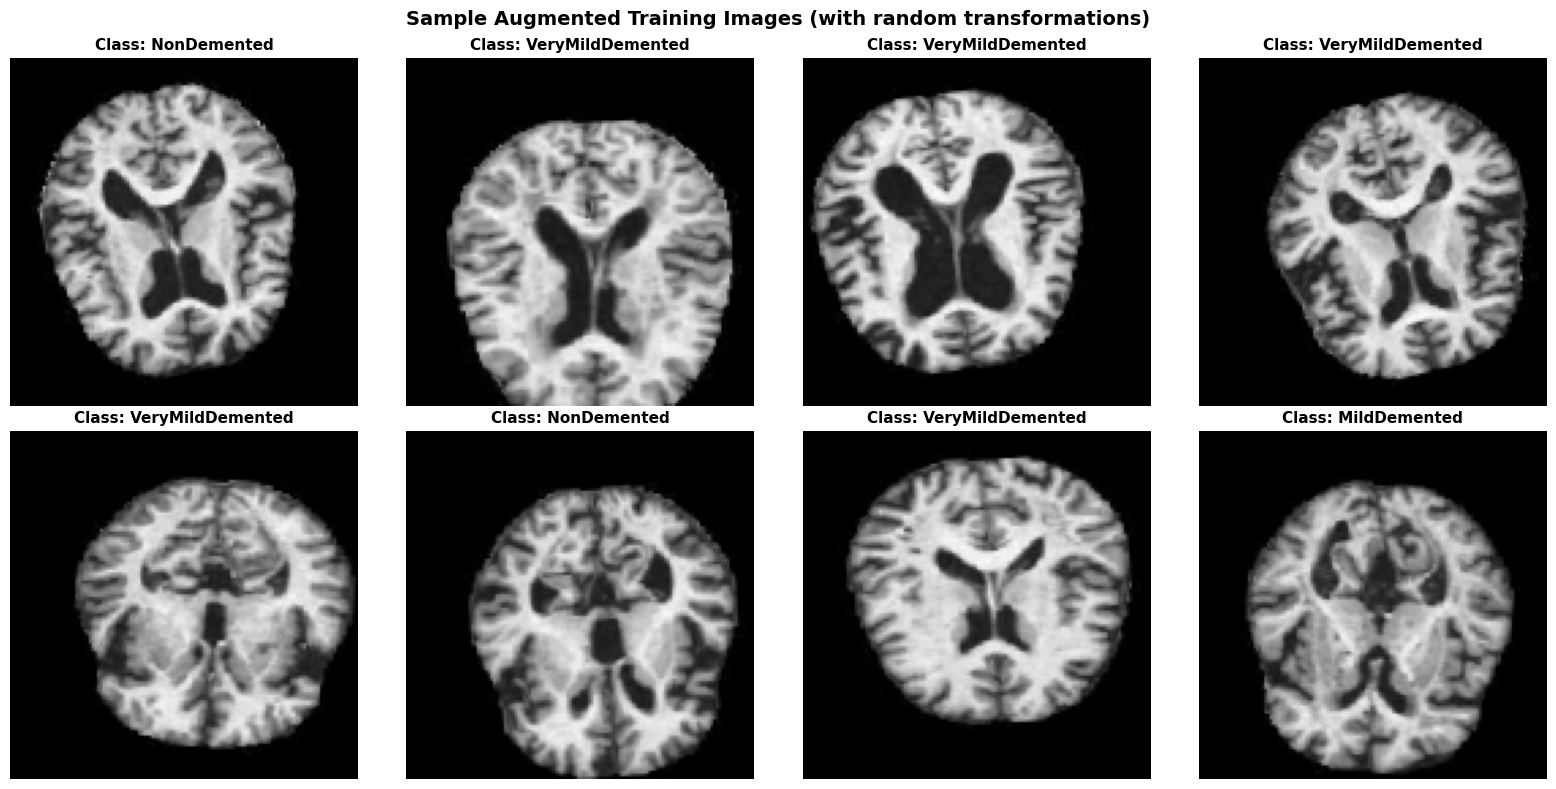


✓ Data generators configured successfully!
✓ Ready for model training!


In [ ]:
# Define image parameters
IMG_SIZE = 128  # Image dimensions (128x128 pixels)
BATCH_SIZE = 32  # Number of images per batch
NUM_CLASSES = len(classes)

print("="*70)
print("CONFIGURING DATA GENERATORS")
print("="*70)
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")

# Data augmentation for TRAINING set only
print("\n" + "-"*70)
print("Training Data Augmentation:")
print("-"*70)
print("  ✓ Rescaling (normalize to 0-1)")
print("  ✓ Rotation (±15 degrees)")
print("  ✓ Width shift (±10%)")
print("  ✓ Height shift (±10%)")
print("  ✓ Shear transformation (10%)")
print("  ✓ Zoom (±10%)")
print("  ✓ Horizontal flip")

train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0,1]
    rotation_range=15,           # Randomly rotate images by ±15 degrees
    width_shift_range=0.1,       # Randomly shift images horizontally
    height_shift_range=0.1,      # Randomly shift images vertically
    shear_range=0.1,             # Shear transformation
    zoom_range=0.1,              # Random zoom
    horizontal_flip=True,        # Randomly flip images horizontally
    fill_mode='nearest'          # Fill in newly created pixels
)

# Only rescaling for validation and test sets (NO augmentation)
print("\nValidation & Test Data:")
print("-"*70)
print("  ✓ Rescaling only (normalize to 0-1)")
print("  ✗ No augmentation")

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
print("\n" + "="*70)
print("CREATING DATA GENERATORS")
print("="*70)

train_generator = train_datagen. flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen. flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✓ Training batches:    {len(train_generator)}")
print(f"✓ Validation batches: {len(val_generator)}")
print(f"✓ Test batches:       {len(test_generator)}")

# Visualize augmented images
print("\n" + "="*70)
print("VISUALIZING AUGMENTED TRAINING IMAGES")
print("="*70)

# Get a batch of augmented images
sample_images, sample_labels = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i in range(8):
    axes[i].imshow(sample_images[i])
    class_idx = np.argmax(sample_labels[i])
    class_name = list(label_mapping.keys())[list(label_mapping.values()).index(class_idx)]
    axes[i].set_title(f'Class: {class_name}', fontweight='bold', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Sample Augmented Training Images (with random transformations)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Reset generator after visualization
train_generator. reset()

print("\n✓ Data generators configured successfully!")
print("✓ Ready for model training!")

**Cell 6: Calculate Class Weights for Imbalanced Data**

CALCULATING CLASS WEIGHTS

Class Weights (to handle imbalance):
----------------------------------------------------------------------
Class0-MildDemented             :Weight=1.7863(Count: 627)
Class1-ModerateDemented         :Weight=24.8889(Count: 45)
Class2-NonDemented              :Weight=0.5000(Count: 2240)
Class3-VeryMildDemented         :Weight=0.7143(Count: 1568)


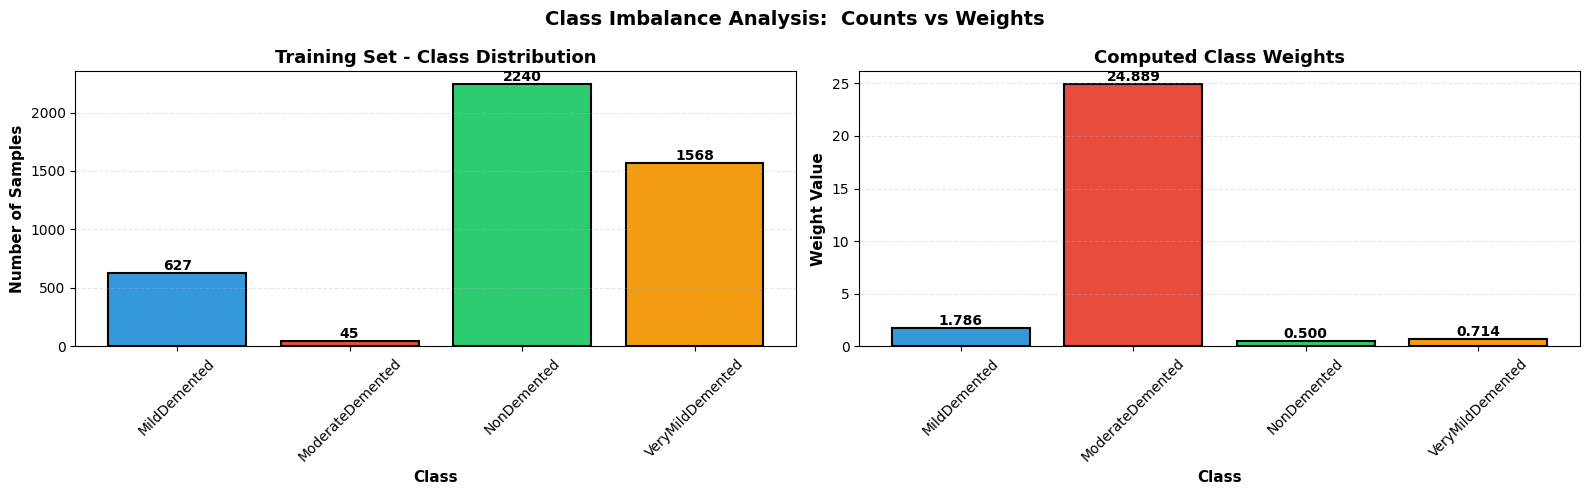


HOW CLASS WEIGHTS WORK:
✓ Classes with FEWER samples get HIGHER weights
✓ Classes with MORE samples get LOWER weights
✓ This forces the model to pay equal attention to all classes
✓ Prevents bias toward the majority class

✓ Class weights calculated successfully!
✓ These will be applied during model training


In [ ]:
# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

print("="*70)
print("CALCULATING CLASS WEIGHTS")
print("="*70)

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_encoded']),
    y=train_df['label_encoded']
)

# Create dictionary mapping class indices to weights
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

print("\nClass Weights (to handle imbalance):")
print("-"*70)

for class_idx in sorted(class_weights.keys()):
    class_name = list(label_mapping.keys())[list(label_mapping.values()).index(class_idx)]
    weight = class_weights[class_idx]
    count = len(train_df[train_df['label_encoded'] == class_idx])
    print(f"Class{class_idx}-{class_name:25s}:Weight={weight:.4f}(Count: {count})")

# Visualize class weights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Class counts
class_names_ordered = [list(label_mapping.keys())[list(label_mapping.values()).index(i)]
                       for i in sorted(class_weights.keys())]
class_counts = [len(train_df[train_df['label_encoded'] == i]) for i in sorted(class_weights.keys())]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars1 = ax1.bar(class_names_ordered, class_counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Training Set - Class Distribution', fontweight='bold', fontsize=13)
ax1.set_xlabel('Class', fontweight='bold', fontsize=11)
ax1.set_ylabel('Number of Samples', fontweight='bold', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar. get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Class weights
weights_ordered = [class_weights[i] for i in sorted(class_weights.keys())]
bars2 = ax2.bar(class_names_ordered, weights_ordered, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Computed Class Weights', fontweight='bold', fontsize=13)
ax2.set_xlabel('Class', fontweight='bold', fontsize=11)
ax2.set_ylabel('Weight Value', fontweight='bold', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Class Imbalance Analysis:  Counts vs Weights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("HOW CLASS WEIGHTS WORK:")
print("="*70)
print("✓ Classes with FEWER samples get HIGHER weights")
print("✓ Classes with MORE samples get LOWER weights")
print("✓ This forces the model to pay equal attention to all classes")
print("✓ Prevents bias toward the majority class")
print("="*70)

print("\n✓ Class weights calculated successfully!")
print("✓ These will be applied during model training")

**Cell 7: Build Transfer Learning Model (VGG16)**

In [ ]:
# Build model using Transfer Learning with VGG16
print("="*70)
print("BUILDING MODEL WITH TRANSFER LEARNING")
print("="*70)

def build_transfer_learning_model(img_size, num_classes):
    """
    Build a model using VGG16 pre-trained on ImageNet
    """
    # Load pre-trained VGG16 model without top layers
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )

    # Freeze the base model layers (don't train them initially)
    base_model.trainable = False

    print("✓ VGG16 base model loaded (pre-trained on ImageNet)")
    print(f"✓ Base model layers frozen: {len(base_model.layers)} layers")

    # Add custom classification layers on top
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    return model

# Build the model
model = build_transfer_learning_model(IMG_SIZE, NUM_CLASSES)

# Compile the model
print("\n" + "-"*70)
print("Compiling Model...")
print("-"*70)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Optimizer: Adam (learning_rate=0.001)")
print("✓ Loss function:  Categorical Crossentropy")
print("✓ Metrics:  Accuracy")

# Display model summary
print("\n" + "="*70)
print("MODEL ARCHITECTURE SUMMARY")
print("="*70)
model.summary()

# Count parameters (FIXED)
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print("\n" + "="*70)
print("PARAMETER SUMMARY")
print("="*70)
print(f"Total parameters:          {total_params:>15,}")
print(f"Trainable parameters:      {trainable_params:>15,}")
print(f"Non-trainable parameters:  {non_trainable_params:>15,}")
print("="*70)

# Visualize model architecture
print("\n" + "="*70)
print("MODEL STRUCTURE")
print("="*70)
print("\n[VGG16 Base (Frozen)]")
print("         ↓")
print("[Global Average Pooling]")
print("         ↓")
print("[Dense 512 + ReLU]")
print("         ↓")
print("[Batch Normalization]")
print("         ↓")
print("[Dropout 0.5]")
print("         ↓")
print("[Dense 256 + ReLU]")
print("         ↓")
print("[Batch Normalization]")
print("         ↓")
print("[Dropout 0.3]")
print("         ↓")
print(f"[Dense {NUM_CLASSES} + Softmax]")
print("         ↓")
print("[Output: 4 Classes]")

print("\n" + "="*70)
print("✓ Model built and compiled successfully!")
print("✓ Ready for training!")
print("="*70)

BUILDING MODEL WITH TRANSFER LEARNING
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ VGG16 base model loaded (pre-trained on ImageNet)
✓ Base model layers frozen: 19 layers

----------------------------------------------------------------------
Compiling Model...
----------------------------------------------------------------------
✓ Optimizer: Adam (learning_rate=0.001)
✓ Loss function:  Categorical Crossentropy
✓ Metrics:  Accuracy

MODEL ARCHITECTURE SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,772 (57.65 MB)

 Trainable params: 396,548 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)


PARAMETER SUMMARY
Total parameters:               15,112,772
Trainable parameters:              396,548
Non-trainable parameters:       14,716,224

MODEL STRUCTURE

[VGG16 Base (Frozen)]
         ↓
[Global Average Pooling]
         ↓
[Dense 512 + ReLU]
         ↓
[Batch Normalization]
         ↓
[Dropout 0.5]
         ↓
[Dense 256 + ReLU]
         ↓
[Batch Normalization]
         ↓
[Dropout 0.3]
         ↓
[Dense 4 + Softmax]
         ↓
[Output: 4 Classes]

✓ Model built and compiled successfully!
✓ Ready for training!


**Cell 8: Setup Callbacks for Training**

In [ ]:
# Define callbacks for training
print("="*70)
print("CONFIGURING TRAINING CALLBACKS")
print("="*70)

callbacks = [
    # Early stopping:  stop training if validation loss doesn't improve
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    # Save the best model
    ModelCheckpoint(
        filepath='/content/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("\n" + "-"*70)
print("Callback 1: Early Stopping")
print("-"*70)
print("  Monitor:   Validation Loss")
print("  Patience: 7 epochs")
print("  Action:   Stop training if no improvement for 7 consecutive epochs")
print("  Benefit:  Prevents overfitting and saves training time")

print("\n" + "-"*70)
print("Callback 2: ReduceLROnPlateau")
print("-"*70)
print("  Monitor:  Validation Loss")
print("  Patience: 3 epochs")
print("  Factor:   0.5 (halves learning rate)")
print("  Min LR:   1e-7")
print("  Action:   Reduces learning rate when stuck at plateau")
print("  Benefit:  Helps model escape local minima")

print("\n" + "-"*70)
print("Callback 3: ModelCheckpoint")
print("-"*70)
print("  Monitor:  Validation Accuracy")
print("  Action:   Saves model when validation accuracy improves")
print("  Location: /content/best_model. h5")
print("  Benefit:  Always keeps the best performing model")

print("\n" + "="*70)
print("✓ Training Callbacks configured successfully!")
print("="*70)

# Visualize callback workflow
print("\n" + "="*70)
print("CALLBACK WORKFLOW DURING TRAINING")
print("="*70)
print("""
Epoch 1, 2, 3...
    ↓
[Model trains]
    ↓
[Validation Loss improves? ]
    ├─ YES → Continue training
    │         ModelCheckpoint saves if val_accuracy improves
    │
    └─ NO  → [Loss plateaus for 3 epochs? ]
              ├─ YES → ReduceLROnPlateau:  Learning Rate ÷ 2
              │
              └─ [Loss still doesn't improve for 7 epochs?]
                    └─ YES → EarlyStopping: Stop training
                              Restore best weights
""")

print("="*70)
print("✓ Ready to start training!")
print("="*70)

CONFIGURING TRAINING CALLBACKS

----------------------------------------------------------------------
Callback 1: Early Stopping
----------------------------------------------------------------------
  Monitor:   Validation Loss
  Patience: 7 epochs
  Action:   Stop training if no improvement for 7 consecutive epochs
  Benefit:  Prevents overfitting and saves training time

----------------------------------------------------------------------
Callback 2: ReduceLROnPlateau
----------------------------------------------------------------------
  Monitor:  Validation Loss
  Patience: 3 epochs
  Factor:   0.5 (halves learning rate)
  Min LR:   1e-7
  Action:   Reduces learning rate when stuck at plateau
  Benefit:  Helps model escape local minima

----------------------------------------------------------------------
Callback 3: ModelCheckpoint
----------------------------------------------------------------------
  Monitor:  Validation Accuracy
  Action:   Saves model when validation ac

**Cell 9: Train the Model**

In [ ]:
# Train the model
print("="*70)
print("STARTING MODEL TRAINING")
print("="*70)
print("This may take 15-30 minutes depending on your hardware...")
print("Please be patient and don't interrupt the training!")
print("="*70)

EPOCHS = 30  # Maximum epochs (may stop earlier due to EarlyStopping)

print(f"\nMaximum Epochs: {EPOCHS}")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Steps per epoch: {len(train_generator)}")
print(f"Validation steps:  {len(val_generator)}")

print("\n" + "="*70)
print("TRAINING IN PROGRESS...")
print("="*70)

# Start training
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)

# Training summary
epochs_trained = len(history.history['accuracy'])
best_train_acc = max(history.history['accuracy'])
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
final_train_loss = history.history['loss'][-1]
final_val_loss = history. history['val_loss'][-1]

print(f"\nEpochs trained:            {epochs_trained}")
print(f"Best training accuracy:   {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best epoch:              {best_epoch}")
print(f"Final training loss:     {final_train_loss:.4f}")
print(f"Final validation loss:   {final_val_loss:.4f}")

# Save training history
import pickle
with open('/content/training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("\n✓ Training history saved to:  /content/training_history.pkl")

# Save final model
model.save('/content/final_model.h5')
print("✓ Final model saved to: /content/final_model.h5")

print("\n" + "="*70)
print("✓ TRAINING COMPLETE!")
print("✓ Best model automatically saved at: /content/best_model.h5")
print("="*70)

STARTING MODEL TRAINING
This may take 15-30 minutes depending on your hardware...
Please be patient and don't interrupt the training!

Maximum Epochs: 30
Training samples: 4480
Validation samples: 960
Batch size: 32
Steps per epoch: 140
Validation steps:  30

TRAINING IN PROGRESS...
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.3237 - loss: 1.9441
Epoch 1: val_accuracy improved from -inf to 0.32917, saving model to /content/best_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - accuracy: 0.3238 - loss: 1.9428 - val_accuracy: 0.3292 - val_loss: 1.3624 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.3829 - loss: 1.3910
Epoch 2: val_accuracy improved from 0.32917 to 0.50521, saving model to /content/best_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step - accuracy: 0.3829 - loss: 1.3910 - val_accuracy: 0.5052 - val_loss: 1.0881 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.3976 - loss: 1.3579
Epoch 3: val_accuracy improved from 0.50521 to 0.50625, saving model to /content/best_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.3977 - loss: 1.3577 - val_accuracy: 0.5063 - val_loss: 1.0884 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.4173 - loss: 1.2160
Epoch 4: val_accuracy did not improve from 0.50625
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step - accuracy: 0.4174 - loss: 1.2155 - val_accuracy: 0.4021 - val_loss: 1.3574 - learning_rate: 0.0010
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4492 - loss: 1.0951
Epoch 5: val_accuracy did not improve from 0.50625
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.4492 - loss: 1.0952 - val_accuracy: 0.4938 - val_loss: 1.0720 - learning_rate: 0.0010
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.4469 - loss: 1.1144
Epoch 6: val_accuracy improved from 0.50625 to 0.57708, saving model to /content/best_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step - accuracy: 0.4469 - loss: 1.1141 - val_accuracy: 0.5771 - val_loss: 0.8772 - learning_rate: 0.0010
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.4708 - loss: 0.9588
Epoch 7: val_accuracy did not improve from 0.57708
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 160ms/step - accuracy: 0.4708 - loss: 0.9591 - val_accuracy: 0.3229 - val_loss: 1.4938 - learning_rate: 0.0010
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.4976 - loss: 0.9738
Epoch 8: val_accuracy did not improve from 0.57708
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step - accuracy: 0.4975 - loss: 0.9739 - val_accuracy: 0.4958 - val_loss: 1.1071 - learning_rate: 0.0010
Epoch 9/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.4765 - loss: 1.0602
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 9: val_accuracy did not improve from 0.57708
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.4765 - loss: 1.0

140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 170ms/step - accuracy: 0.5165 - loss: 0.8619 - val_accuracy: 0.5875 - val_loss: 0.8547 - learning_rate: 2.5000e-04
Epoch 14/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5250 - loss: 0.8697
Epoch 14: val_accuracy did not improve from 0.58750
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step - accuracy: 0.5250 - loss: 0.8693 - val_accuracy: 0.5229 - val_loss: 0.9707 - learning_rate: 2.5000e-04
Epoch 15/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5342 - loss: 0.8150
Epoch 15: val_accuracy did not improve from 0.58750
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step - accuracy: 0.5342 - loss: 0.8151 - val_accuracy: 0.5063 - val_loss: 1.0593 - learning_rate: 2.5000e-04
Epoch 16/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.5223 - loss: 0.8011
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 16: val_accuracy did not improve from 0.58750
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step - accuracy:


TRAINING COMPLETED!

Epochs trained:            20
Best training accuracy:   0.5404 (54.04%)
Best validation accuracy: 0.5875 (58.75%)
Best epoch:              13
Final training loss:     0.7948
Final validation loss:   0.8936

✓ Training history saved to:  /content/training_history.pkl
✓ Final model saved to: /content/final_model.h5

✓ TRAINING COMPLETE!
✓ Best model automatically saved at: /content/best_model.h5


**Cell 10: Plot Training History and Analysis**

VISUALIZING TRAINING HISTORY


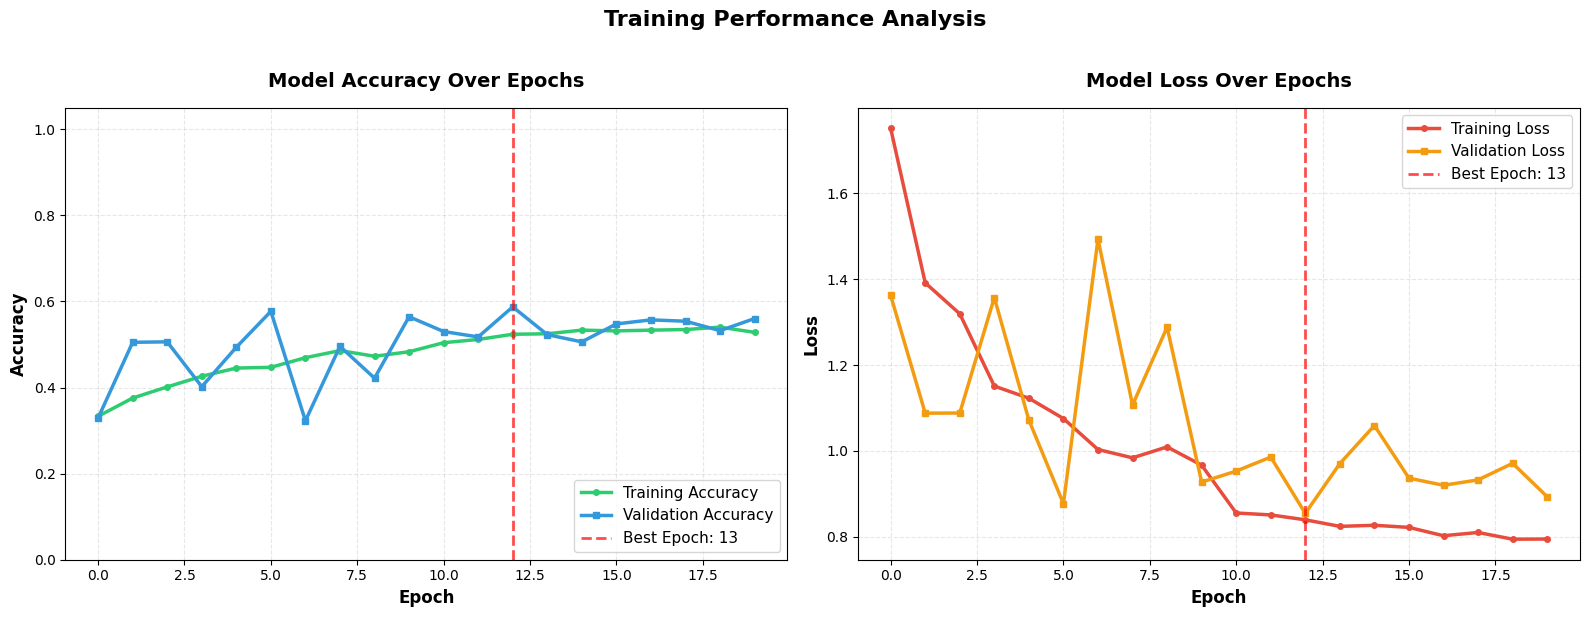

✓ Training curves saved to: /content/training_history.png

TRAINING ANALYSIS

Total Epochs Trained:       20
Best Epoch:                 13

Best Training Accuracy:     0.5404 (54.04%)
Best Validation Accuracy:   0.5875 (58.75%)

Final Training Accuracy:    0.5283 (52.83%)
Final Validation Accuracy:  0.5604 (56.04%)

Accuracy Gap (Train - Val): -0.0471 (-4.71%)

✓ Good generalization!  Model is not overfitting

LEARNING CURVE INSIGHTS
 NEEDS IMPROVEMENT: Validation accuracy < 65%



In [ ]:
# Plot training history
print("="*70)
print("VISUALIZING TRAINING HISTORY")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy over epochs
axes[0]. plot(history.history['accuracy'], label='Training Accuracy',
             linewidth=2.5, marker='o', markersize=4, color='#2ecc71')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy',
             linewidth=2.5, marker='s', markersize=4, color='#3498db')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 1.05])

# Mark best epoch
best_epoch_idx = history.history['val_accuracy'].index(max(history. history['val_accuracy']))
axes[0].axvline(x=best_epoch_idx, color='red', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Best Epoch: {best_epoch_idx+1}')
axes[0].legend(loc='lower right', fontsize=11)

# Plot 2: Loss over epochs
axes[1].plot(history.history['loss'], label='Training Loss',
             linewidth=2.5, marker='o', markersize=4, color='#e74c3c')
axes[1].plot(history. history['val_loss'], label='Validation Loss',
             linewidth=2.5, marker='s', markersize=4, color='#f39c12')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')

# Mark best epoch
axes[1].axvline(x=best_epoch_idx, color='red', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Best Epoch: {best_epoch_idx+1}')
axes[1].legend(loc='upper right', fontsize=11)

plt.suptitle('Training Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to: /content/training_history.png")

# Detailed analysis
print("\n" + "="*70)
print("TRAINING ANALYSIS")
print("="*70)

epochs_trained = len(history.history['accuracy'])
best_train_acc = max(history.history['accuracy'])
best_val_acc = max(history.history['val_accuracy'])
best_epoch = best_epoch_idx + 1
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nTotal Epochs Trained:       {epochs_trained}")
print(f"Best Epoch:                 {best_epoch}")
print(f"\nBest Training Accuracy:     {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
print(f"Best Validation Accuracy:   {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"\nFinal Training Accuracy:    {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Validation Accuracy:  {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

# Check for overfitting
gap = best_train_acc - best_val_acc
print(f"\nAccuracy Gap (Train - Val): {gap:.4f} ({gap*100:.2f}%)")

if gap > 0.1:
    print("\n  WARNING: Significant overfitting detected!")
    print("   Training accuracy is much higher than validation accuracy")
    print("   Recommendations:  Increase dropout, add more data augmentation")
elif gap > 0.05:
    print("\n  Mild overfitting detected")
    print("   Model performs slightly better on training data")
else:
    print("\n✓ Good generalization!  Model is not overfitting")

# Learning curve analysis
print("\n" + "="*70)
print("LEARNING CURVE INSIGHTS")
print("="*70)

if final_val_acc > 0.85:
    print("✓ EXCELLENT:  Validation accuracy > 85%")
elif final_val_acc > 0.75:
    print("✓ GOOD: Validation accuracy > 75%")
elif final_val_acc > 0.65:
    print("  MODERATE:  Validation accuracy > 65%")
else:
    print(" NEEDS IMPROVEMENT: Validation accuracy < 65%")

print("\n" + "="*70)

**Cell 11: Load Best Model and Evaluate on Test Set**

In [ ]:
# Load the best saved model
from tensorflow.keras.models import load_model

print("="*70)
print("LOADING BEST MODEL AND EVALUATING ON TEST SET")
print("="*70)

best_model = load_model('/content/best_model.h5')
print("✓ Best model loaded successfully from: /content/best_model. h5")

# Evaluate on test set
print("\n" + "-"*70)
print("Evaluating on Test Set...")
print("-"*70)

test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)

print("\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Test Loss:{test_loss:.4f}")
print(f"Test Accuracy:{test_accuracy:.4f}({test_accuracy*100:.2f}%)")
print("="*70)

# Make predictions on test set
print("\n" + "-"*70)
print("Generating Predictions...")
print("-"*70)

test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_df['label_encoded'].values

print(f"\n✓ Predictions completed for{len(predicted_classes)}test samples")

# Calculate per-class accuracy
print("\n" + "="*70)
print("PER-CLASS PREDICTION SUMMARY")
print("="*70)

for class_idx in sorted(label_mapping.values()):
    class_name = list(label_mapping.keys())[list(label_mapping.values()).index(class_idx)]

    # Get samples for this class
    class_mask = (true_classes == class_idx)
    class_total = np.sum(class_mask)
    class_correct = np.sum((true_classes == class_idx) & (predicted_classes == class_idx))
    class_accuracy = class_correct / class_total if class_total > 0 else 0

    print(f"Class{class_idx}-{class_name:25s}:{class_correct:3d}/{class_total:3d}correct({class_accuracy*100:5.2f}%)")

# Overall statistics
total_correct = np.sum(predicted_classes == true_classes)
total_samples = len(true_classes)

print("-"*70)
print(f"{'TOTAL':30s}:{total_correct:3d}/{total_samples:3d}correct({test_accuracy*100:5.2f}%)")
print("="*70)

# Save predictions for later analysis
predictions_df = pd.DataFrame({
    'filepath': test_df['filepath']. values,
    'true_label': test_df['label']. values,
    'true_class': true_classes,
    'predicted_class': predicted_classes,
    'correct': predicted_classes == true_classes
})

# Add prediction probabilities
for class_idx in range(NUM_CLASSES):
    class_name = list(label_mapping.keys())[list(label_mapping.values()).index(class_idx)]
    predictions_df[f'prob_{class_name}'] = predictions[:, class_idx]

predictions_df.to_csv('/content/test_predictions.csv', index=False)
print("\n✓ Detailed predictions saved to:   /content/test_predictions. csv")

# Quick summary
correct_count = predictions_df['correct'].sum()
incorrect_count = len(predictions_df) - correct_count

print(f"\n✓ Correct predictions:{correct_count}({correct_count/len(predictions_df)*100:.2f}%)")
print(f"✗ Incorrect predictions:{incorrect_count}({incorrect_count/len(predictions_df)*100:.2f}%)")

print("\n" + "="*70)
print("✓ TEST EVALUATION COMPLETED!")
print("="*70)

LOADING BEST MODEL AND EVALUATING ON TEST SET


✓ Best model loaded successfully from: /content/best_model. h5

----------------------------------------------------------------------
Evaluating on Test Set...
----------------------------------------------------------------------
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5645 - loss: 0.8688

TEST SET RESULTS
Test Loss:0.8518
Test Accuracy:0.5813(58.13%)

----------------------------------------------------------------------
Generating Predictions...
----------------------------------------------------------------------
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step

✓ Predictions completed for960test samples

PER-CLASS PREDICTION SUMMARY
Class0-MildDemented             : 98/135correct(72.59%)
Class1-ModerateDemented         :  9/  9correct(100.00%)
Class2-NonDemented              :342/480correct(71.25%)
Class3-VeryMildDemented         :109/336correct(32.44%)
----------------------------------------------------------------------
TOTAL                         :558/960correct(58.13

**Cell 12: Generate and Visualize Confusion Matrix**

GENERATING CONFUSION MATRIX

Confusion Matrix (raw counts):
[[ 98   5  16  16]
 [  0   9   0   0]
 [ 67   5 342  66]
 [ 89  11 127 109]]


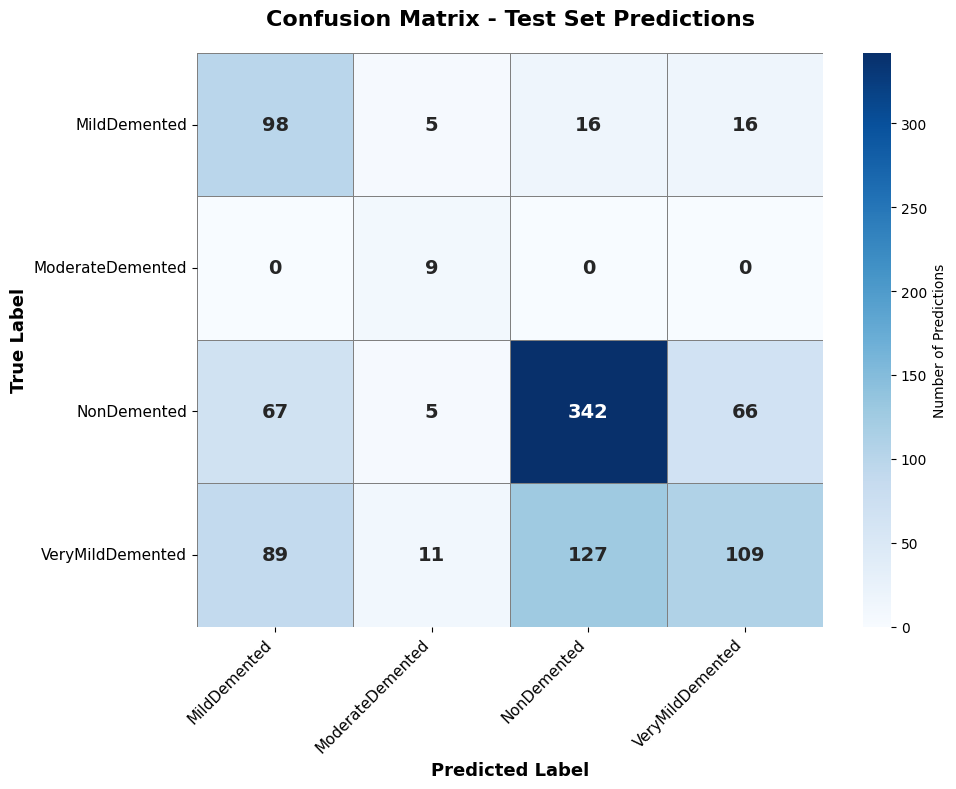


✓ Confusion matrix saved to:   /content/confusion_matrix.png

PER-CLASS ACCURACY FROM CONFUSION MATRIX

MildDemented:
  Accuracy:  98/135 = 72.59%
  Most confused with:   NonDemented (16 times)

ModerateDemented:
  Accuracy:  9/9 = 100.00%
  Perfect classification!   ✓

NonDemented:
  Accuracy:  342/480 = 71.25%
  Most confused with:   MildDemented (67 times)

VeryMildDemented:
  Accuracy:  109/336 = 32.44%
  Most confused with:   NonDemented (127 times)

NORMALIZED CONFUSION MATRIX (Percentages)


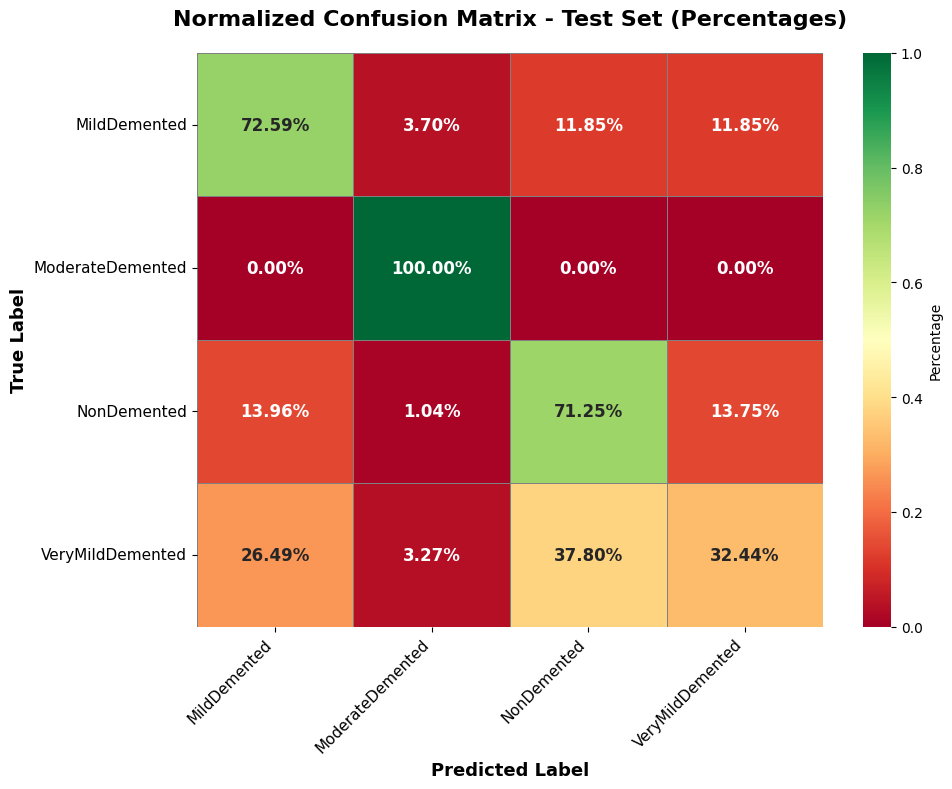


✓ Normalized confusion matrix saved to:  /content/confusion_matrix_normalized.png

CONFUSION MATRIX INTERPRETATION
• Diagonal values (dark): Correct predictions
• Off-diagonal values (light): Misclassifications
• Rows represent TRUE labels
• Columns represent PREDICTED labels


In [ ]:
# Generate confusion matrix
from sklearn.metrics import confusion_matrix

print("="*70)
print("GENERATING CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(true_classes, predicted_classes)

print("\nConfusion Matrix (raw counts):")
print(cm)

# Create class names list in order
class_names_ordered = [list(label_mapping.keys())[list(label_mapping.values()).index(i)]
                       for i in range(NUM_CLASSES)]

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_ordered,
            yticklabels=class_names_ordered,
            cbar_kws={'label': 'Number of Predictions'},
            linewidths=0.5, linecolor='gray',
            annot_kws={'fontsize':  14, 'fontweight': 'bold'})

plt.title('Confusion Matrix - Test Set Predictions', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt. xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confusion matrix saved to:   /content/confusion_matrix.png")

# Calculate and display per-class metrics from confusion matrix
print("\n" + "="*70)
print("PER-CLASS ACCURACY FROM CONFUSION MATRIX")
print("="*70)

for i, class_name in enumerate(class_names_ordered):
    class_correct = cm[i, i]
    class_total = cm[i, : ].sum()
    class_accuracy = class_correct / class_total if class_total > 0 else 0

    # Find most common misclassification
    misclassifications = cm[i, : ].copy()
    misclassifications[i] = 0  # Exclude correct predictions

    if misclassifications.sum() > 0:
        most_confused_idx = np.argmax(misclassifications)
        most_confused_class = class_names_ordered[most_confused_idx]
        most_confused_count = misclassifications[most_confused_idx]

        print(f"\n{class_name}:")
        print(f"  Accuracy:  {class_correct}/{class_total} = {class_accuracy*100:.2f}%")
        print(f"  Most confused with:   {most_confused_class} ({most_confused_count} times)")
    else:
        print(f"\n{class_name}:")
        print(f"  Accuracy:  {class_correct}/{class_total} = {class_accuracy*100:.2f}%")
        print(f"  Perfect classification!   ✓")

# Normalized confusion matrix (percentages)
print("\n" + "="*70)
print("NORMALIZED CONFUSION MATRIX (Percentages)")
print("="*70)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=class_names_ordered,
            yticklabels=class_names_ordered,
            cbar_kws={'label':  'Percentage'},
            linewidths=0.5, linecolor='gray',
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            vmin=0, vmax=1)

plt.title('Normalized Confusion Matrix - Test Set (Percentages)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Normalized confusion matrix saved to:  /content/confusion_matrix_normalized.png")

print("\n" + "="*70)
print("CONFUSION MATRIX INTERPRETATION")
print("="*70)
print("• Diagonal values (dark): Correct predictions")
print("• Off-diagonal values (light): Misclassifications")
print("• Rows represent TRUE labels")
print("• Columns represent PREDICTED labels")
print("="*70)

**Cell 13: Generate Detailed Classification Report**

DETAILED CLASSIFICATION REPORT

                  precision    recall  f1-score   support

    MildDemented     0.3858    0.7259    0.5039       135
ModerateDemented     0.3000    1.0000    0.4615         9
     NonDemented     0.7052    0.7125    0.7088       480
VeryMildDemented     0.5707    0.3244    0.4137       336

        accuracy                         0.5813       960
       macro avg     0.4904    0.6907    0.5220       960
    weighted avg     0.6094    0.5813    0.5744       960


✓ Classification report saved to: /content/classification_report.txt

METRICS SUMMARY TABLE
           Class  Precision   Recall  F1-Score  Support
    MildDemented   0.385827 0.725926  0.503856      135
ModerateDemented   0.300000 1.000000  0.461538        9
     NonDemented   0.705155 0.712500  0.708808      480
VeryMildDemented   0.570681 0.324405  0.413662      336


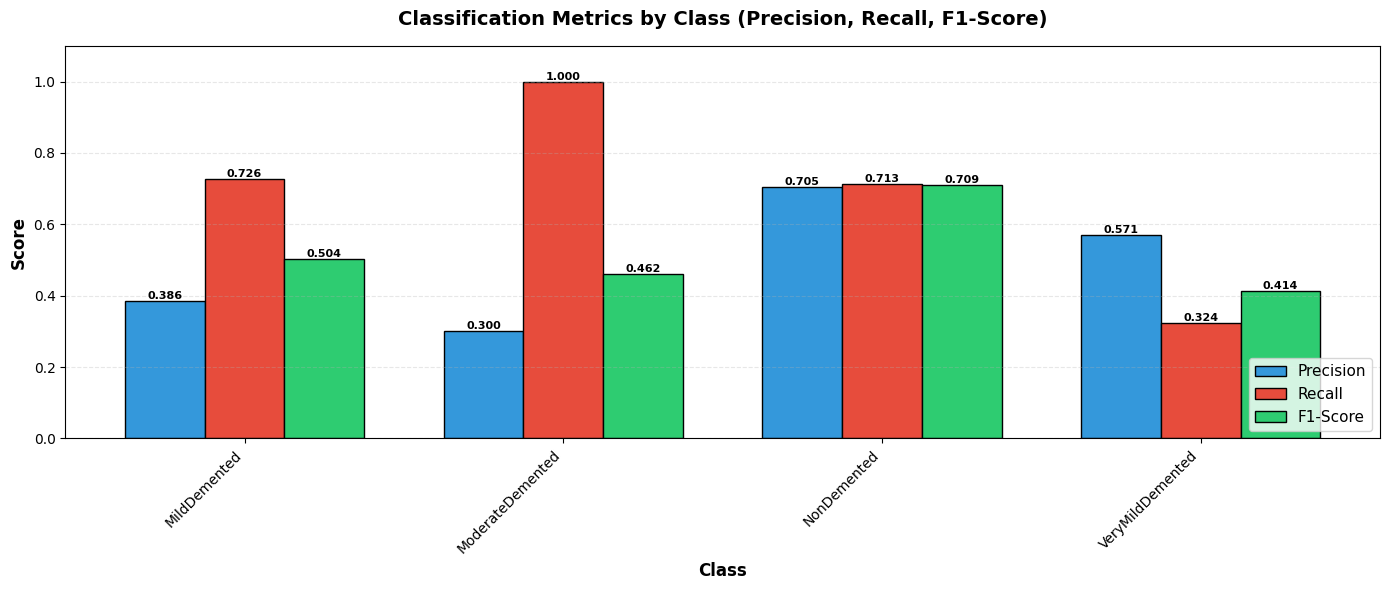


✓ Metrics comparison saved to: /content/metrics_comparison.png

METRICS EXPLANATION
• Precision: Of all predictions for a class, how many were correct?
             (High precision = Few false positives)

• Recall:     Of all actual samples of a class, how many were found?
             (High recall = Few false negatives)

• F1-Score:  Harmonic mean of Precision and Recall
             (Balanced measure of both)

• Support:   Number of actual samples for each class


In [ ]:
# Generate detailed classification report
from sklearn.metrics import classification_report, precision_recall_fscore_support

print("="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names_ordered,
    digits=4
)
print("\n" + report)

# Save report to file
with open('/content/classification_report.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("ALZHEIMER'S MRI CLASSIFICATION - DETAILED REPORT\n")
    f.write("="*70 + "\n\n")
    f.write(report)
    f.write("\n\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")

print("\n✓ Classification report saved to: /content/classification_report.txt")

# Get metrics for visualization
precision, recall, f1, support = precision_recall_fscore_support(
    true_classes, predicted_classes, average=None
)

# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Class': class_names_ordered,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\n" + "="*70)
print("METRICS SUMMARY TABLE")
print("="*70)
print(metrics_df.to_string(index=False))

# Visualize metrics comparison
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_names_ordered))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#3498db', edgecolor='black')
bars2 = ax.bar(x, recall, width, label='Recall', color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#2ecc71', edgecolor='black')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Classification Metrics by Class (Precision, Recall, F1-Score)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(class_names_ordered, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar. get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Metrics comparison saved to: /content/metrics_comparison.png")

# Explanation of metrics
print("\n" + "="*70)
print("METRICS EXPLANATION")
print("="*70)
print("• Precision: Of all predictions for a class, how many were correct?")
print("             (High precision = Few false positives)")
print("")
print("• Recall:     Of all actual samples of a class, how many were found?")
print("             (High recall = Few false negatives)")
print("")
print("• F1-Score:  Harmonic mean of Precision and Recall")
print("             (Balanced measure of both)")
print("")
print("• Support:   Number of actual samples for each class")
print("="*70)

**Cell 14: Visualize Correct and Incorrect Predictions**

VISUALIZING SAMPLE PREDICTIONS

Total correct predictions:    558
Total incorrect predictions:  402

----------------------------------------------------------------------
CORRECT PREDICTIONS
----------------------------------------------------------------------


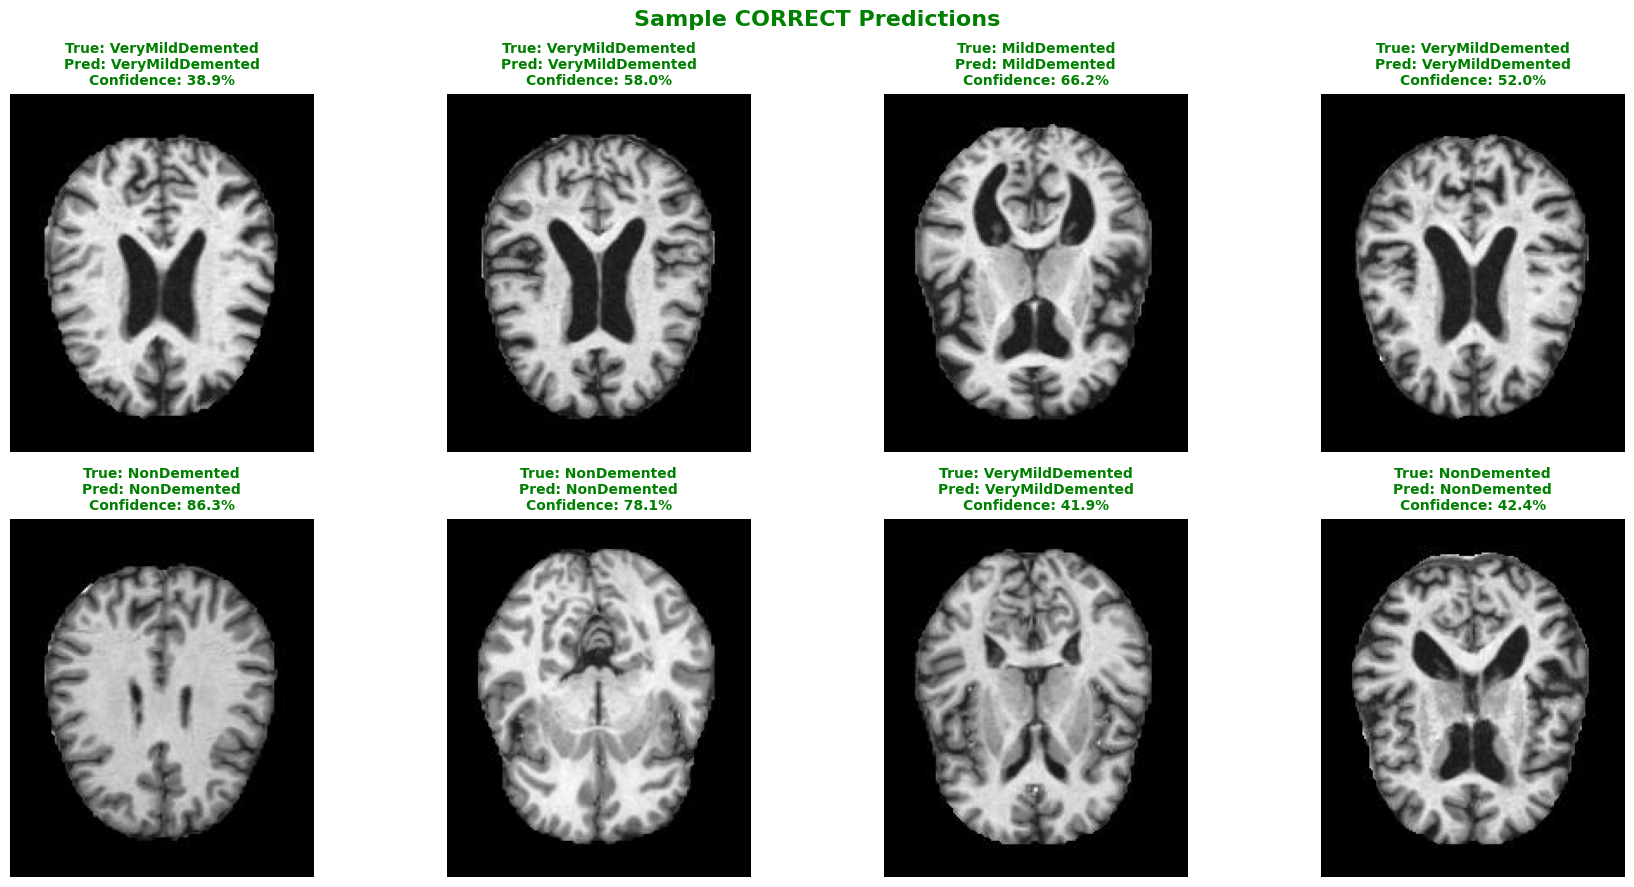

✓ Correct predictions visualization saved

----------------------------------------------------------------------
INCORRECT PREDICTIONS
----------------------------------------------------------------------


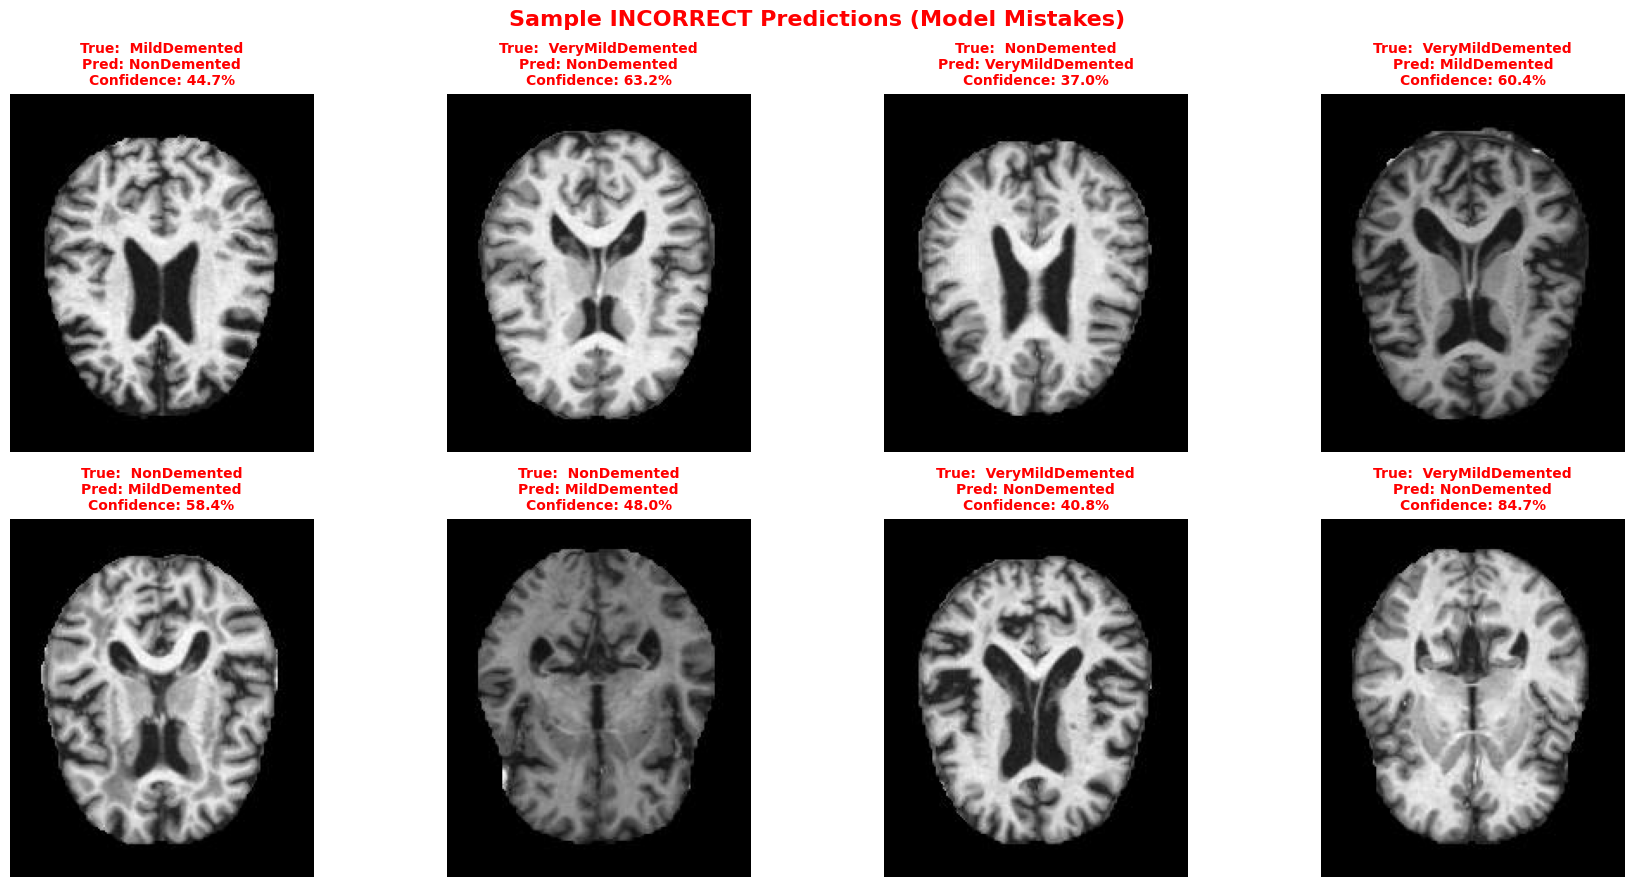

✓ Incorrect predictions visualization saved

MISCLASSIFICATION ANALYSIS

Misclassification:
True class:MildDemented
Predicted as:NonDemented
Confidence:44.74%
All probabilities:
MildDemented             :33.37%
ModerateDemented         : 2.18%
NonDemented              :44.74%
VeryMildDemented         :19.71%
----------------------------------------------------------------------

Misclassification:
True class:VeryMildDemented
Predicted as:NonDemented
Confidence:63.25%
All probabilities:
MildDemented             : 1.17%
ModerateDemented         : 0.01%
NonDemented              :63.25%
VeryMildDemented         :35.58%
----------------------------------------------------------------------

Misclassification:
True class:NonDemented
Predicted as:VeryMildDemented
Confidence:37.03%
All probabilities:
MildDemented             :28.96%
ModerateDemented         : 5.31%
NonDemented              :28.69%
VeryMildDemented         :37.03%
----------------------------------------------------------------

In [ ]:
# Visualize sample predictions
print("="*70)
print("VISUALIZING SAMPLE PREDICTIONS")
print("="*70)

# Find correct and incorrect predictions
correct_indices = np.where(predicted_classes == true_classes)[0]
incorrect_indices = np. where(predicted_classes != true_classes)[0]

print(f"\nTotal correct predictions:    {len(correct_indices)}")
print(f"Total incorrect predictions:  {len(incorrect_indices)}")

# Sample correct predictions
num_correct_samples = min(8, len(correct_indices))
correct_sample = np.random.choice(correct_indices, num_correct_samples, replace=False)

print(f"\n" + "-"*70)
print("CORRECT PREDICTIONS")
print("-"*70)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for i, idx in enumerate(correct_sample):
    img_path = test_df.iloc[idx]['filepath']
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    true_label = class_names_ordered[true_classes[idx]]
    pred_label = class_names_ordered[predicted_classes[idx]]
    confidence = predictions[idx][predicted_classes[idx]] * 100

    axes[i].imshow(img)
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConfidence: {confidence:.1f}%',
                     fontsize=10, color='green', fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample CORRECT Predictions', fontsize=16, fontweight='bold', color='green')
plt.tight_layout()
plt.savefig('/content/correct_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correct predictions visualization saved")

# Sample incorrect predictions
if len(incorrect_indices) > 0:
    num_incorrect_samples = min(8, len(incorrect_indices))
    incorrect_sample = np.random.choice(incorrect_indices, num_incorrect_samples, replace=False)

    print(f"\n" + "-"*70)
    print("INCORRECT PREDICTIONS")
    print("-"*70)

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes = axes.ravel()

    for i, idx in enumerate(incorrect_sample):
        img_path = test_df.iloc[idx]['filepath']
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        true_label = class_names_ordered[true_classes[idx]]
        pred_label = class_names_ordered[predicted_classes[idx]]
        confidence = predictions[idx][predicted_classes[idx]] * 100

        axes[i].imshow(img)
        axes[i].set_title(f'True:  {true_label}\nPred: {pred_label}\nConfidence: {confidence:.1f}%',
                         fontsize=10, color='red', fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Sample INCORRECT Predictions (Model Mistakes)', fontsize=16, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig('/content/incorrect_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Incorrect predictions visualization saved")

    # Analyze incorrect predictions
    print("\n" + "="*70)
    print("MISCLASSIFICATION ANALYSIS")
    print("="*70)

    for idx in incorrect_sample:
        true_label = class_names_ordered[true_classes[idx]]
        pred_label = class_names_ordered[predicted_classes[idx]]
        confidence = predictions[idx][predicted_classes[idx]] * 100

        print(f"\nMisclassification:")
        print(f"True class:{true_label}")
        print(f"Predicted as:{pred_label}")
        print(f"Confidence:{confidence:.2f}%")
        print(f"All probabilities:")
        for j, class_name in enumerate(class_names_ordered):
            print(f"{class_name:25s}:{predictions[idx][j]*100:5.2f}%")
        print("-"*70)

else:
    print("\n🎉 PERFECT!  No incorrect predictions found!")
    print("   The model achieved 100% accuracy on the test set!")

print("\n" + "="*70)

Cell 15: Create Inference Function for New Predictions

CREATING INFERENCE FUNCTION
✓ Inference function created successfully!

TESTING INFERENCE FUNCTION

Test Image:  /content/alzheimer-mri-4-classes-dataset/Alzheimer_MRI_4_classes_dataset/MildDemented/23 (22).jpg
True Label: MildDemented

Running prediction.. .



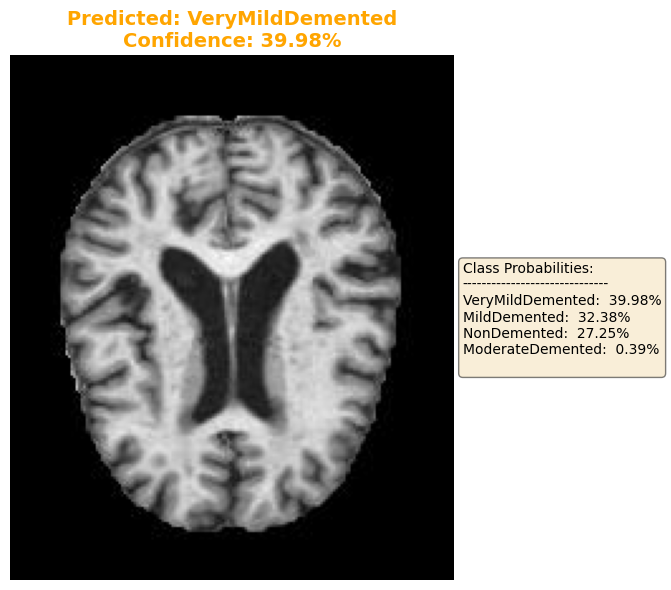


PREDICTION RESULT
Predicted Class:   VeryMildDemented
Confidence:       39.98%
True Label:       MildDemented
Correct:           ✗ NO

✓ Inference function is ready for deployment!
✓ You can now use this function to predict any new MRI image

✓ Inference function code saved to: /content/inference_function.py


In [ ]:
# Create inference function for predicting new images
print("="*70)
print("CREATING INFERENCE FUNCTION")
print("="*70)

def predict_alzheimer(image_path, model, img_size=128, show_image=True):
    """
    Predict Alzheimer's disease class for a new MRI image

    Args:
        image_path: Path to the MRI image
        model: Trained Keras model
        img_size: Image size (default 128)
        show_image:  Whether to display the image with prediction

    Returns:
        predicted_class: Name of predicted class
        confidence: Confidence score (0-1)
        all_probabilities: Dictionary with probabilities for all classes
    """
    # Load and preprocess image
    img = cv2.imread(image_path)
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img_display, (img_size, img_size))
    img_normalized = img / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Make prediction
    predictions = model.predict(img_batch, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]

    # Get class name
    predicted_class = class_names_ordered[predicted_class_idx]

    # Create probability dictionary
    prob_dict = {class_names_ordered[i]: predictions[0][i] for i in range(len(predictions[0]))}

    # Display image with prediction
    if show_image:
        plt.figure(figsize=(10, 6))
        plt.imshow(img_display)
        plt.title(f'Predicted: {predicted_class}\nConfidence: {confidence*100:.2f}%',
                 fontsize=14, fontweight='bold',
                 color='green' if confidence > 0.8 else 'orange')
        plt.axis('off')

        # Add probability text
        prob_text = "Class Probabilities:\n" + "-"*30 + "\n"
        for class_name, prob in sorted(prob_dict.items(), key=lambda x: x[1], reverse=True):
            prob_text += f"{class_name}:  {prob*100:.2f}%\n"

        plt.text(1.02, 0.5, prob_text, transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.tight_layout()
        plt.show()

    return predicted_class, confidence, prob_dict

print("✓ Inference function created successfully!")

# Test the inference function
print("\n" + "="*70)
print("TESTING INFERENCE FUNCTION")
print("="*70)

# Test on a random sample from test set
sample_idx = np.random.choice(len(test_df))
sample_image_path = test_df.iloc[sample_idx]['filepath']
true_label = test_df.iloc[sample_idx]['label']

print(f"\nTest Image:  {sample_image_path}")
print(f"True Label: {true_label}")
print("\nRunning prediction.. .\n")

pred_class, confidence, probabilities = predict_alzheimer(
    sample_image_path,
    best_model,
    IMG_SIZE,
    show_image=True
)

print(f"\n{'='*70}")
print("PREDICTION RESULT")
print(f"{'='*70}")
print(f"Predicted Class:   {pred_class}")
print(f"Confidence:       {confidence*100:.2f}%")
print(f"True Label:       {true_label}")
print(f"Correct:           {'✓ YES' if pred_class == true_label else '✗ NO'}")

print("\n" + "="*70)
print("✓ Inference function is ready for deployment!")
print("✓ You can now use this function to predict any new MRI image")
print("="*70)

# Save the inference function code
inference_code = '''
# Alzheimer's MRI Classification - Inference Function
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def predict_alzheimer(image_path, model, img_size=128, show_image=True):
    """
    Predict Alzheimer's disease class for a new MRI image

    Args:
        image_path: Path to the MRI image
        model:  Trained Keras model
        img_size: Image size (default 128)
        show_image:  Whether to display the image with prediction

    Returns:
        predicted_class: Name of predicted class
        confidence: Confidence score (0-1)
        all_probabilities: Dictionary with probabilities for all classes
    """
    class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

    # Load and preprocess image
    img = cv2.imread(image_path)
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img_display, (img_size, img_size))
    img_normalized = img / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Make prediction
    predictions = model.predict(img_batch, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]

    # Get class name
    predicted_class = class_names[predicted_class_idx]

    # Create probability dictionary
    prob_dict = {class_names[i]: predictions[0][i] for i in range(len(predictions[0]))}

    # Display image with prediction
    if show_image:
        plt.figure(figsize=(10, 6))
        plt.imshow(img_display)
        plt.title(f'Predicted: {predicted_class}\\nConfidence: {confidence*100:.2f}%',
                 fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.show()

    return predicted_class, confidence, prob_dict

# Usage example:
# model = load_model('best_model.h5')
# pred_class, conf, probs = predict_alzheimer('path/to/image.jpg', model)
'''

with open('/content/inference_function.py', 'w') as f:
    f.write(inference_code)

print("\n✓ Inference function code saved to: /content/inference_function.py")

Cell 16: Save Everything to Google Drive

In [ ]:
# Mount Google Drive (if not already mounted)
from google.colab import drive
drive. mount('/content/drive', force_remount=False)

# Create project folder in Google Drive
import os
from datetime import datetime

project_folder = '/content/drive/MyDrive/Alzheimer_MRI_Project'
os.makedirs(project_folder, exist_ok=True)

print("="*70)
print("SAVING ALL FILES TO GOOGLE DRIVE")
print("="*70)
print(f"\nProject Folder: {project_folder}\n")

# List of files to copy
files_to_save = {
    'Models': [
        '/content/best_model.h5',
        '/content/final_model.h5'
    ],
    'Data': [
        '/content/label_mapping.json',
        '/content/training_history.pkl',
        '/content/test_predictions.csv'
    ],
    'Visualizations': [
        '/content/training_history.png',
        '/content/confusion_matrix.png',
        '/content/confusion_matrix_normalized.png',
        '/content/metrics_comparison.png',
        '/content/correct_predictions.png',
        '/content/incorrect_predictions.png'
    ],
    'Reports': [
        '/content/classification_report.txt',
        '/content/inference_function.py'
    ]
}

# Copy files
import shutil

for category, files in files_to_save.items():
    category_folder = os.path.join(project_folder, category)
    os.makedirs(category_folder, exist_ok=True)

    print(f"\n{category}:")
    print("-"*70)

    for file_path in files:
        if os.path.exists(file_path):
            filename = os.path.basename(file_path)
            destination = os.path.join(category_folder, filename)
            shutil.copy(file_path, destination)
            print(f"  ✓ {filename}")
        else:
            print(f"  ✗ {filename} (not found)")

# Create a project summary file
summary_file = os.path.join(project_folder, 'PROJECT_SUMMARY.txt')

with open(summary_file, 'w') as f:
    f.write("="*70 + "\n")
    f.write("ALZHEIMER'S MRI CLASSIFICATION PROJECT - SUMMARY\n")
    f.write("="*70 + "\n\n")

    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    f.write("DATASET INFORMATION\n")
    f.write("-"*70 + "\n")
    f.write(f"Total Images:  {len(df)}\n")
    f.write(f"Number of Classes: {NUM_CLASSES}\n")
    f.write(f"Classes: {', '.join(class_names_ordered)}\n")
    f.write(f"Training Samples: {len(train_df)}\n")
    f.write(f"Validation Samples: {len(val_df)}\n")
    f.write(f"Test Samples: {len(test_df)}\n\n")

    f.write("MODEL INFORMATION\n")
    f.write("-"*70 + "\n")
    f.write(f"Architecture: VGG16 Transfer Learning\n")
    f.write(f"Image Size: {IMG_SIZE}x{IMG_SIZE}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Total Parameters: {total_params: ,}\n")
    f.write(f"Trainable Parameters: {trainable_params:,}\n\n")

    f.write("TRAINING INFORMATION\n")
    f.write("-"*70 + "\n")
    f.write(f"Epochs Trained: {len(history.history['accuracy'])}\n")
    f.write(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}\n")
    f.write(f"Optimizer: Adam (lr=0.001)\n")
    f.write(f"Loss Function:  Categorical Crossentropy\n")
    f.write(f"Data Augmentation: Yes\n")
    f.write(f"Class Weights: Applied\n\n")

    f.write("TEST SET PERFORMANCE\n")
    f.write("-"*70 + "\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)\n")
    f.write(f"Test Loss: {test_loss:.4f}\n\n")

    f.write("PER-CLASS ACCURACY\n")
    f.write("-"*70 + "\n")
    for i, class_name in enumerate(class_names_ordered):
        class_mask = (true_classes == i)
        class_total = np.sum(class_mask)
        class_correct = np.sum((true_classes == i) & (predicted_classes == i))
        class_acc = class_correct / class_total if class_total > 0 else 0
        f.write(f"{class_name}: {class_acc:.4f} ({class_acc*100:.2f}%)\n")

    f.write("\n" + "="*70 + "\n")
    f.write("PROJECT FILES SAVED IN:\n")
    f.write(f"{project_folder}\n")
    f.write("="*70 + "\n")

print("\n" + "="*70)
print("✓ PROJECT SUMMARY SAVED")
print("="*70)

# Display folder structure
print("\n" + "="*70)
print("GOOGLE DRIVE FOLDER STRUCTURE")
print("="*70)
print(f"\n{project_folder}/")
for category in files_to_save. keys():
    print(f"  ├── {category}/")
    category_folder = os.path.join(project_folder, category)
    if os.path.exists(category_folder):
        files = os.listdir(category_folder)
        for i, file in enumerate(files):
            if i == len(files) - 1:
                print(f"  │   └── {file}")
            else:
                print(f"  │   ├── {file}")
print(f"  └── PROJECT_SUMMARY.txt")

print("\n" + "="*70)
print("✓ ALL FILES SAVED TO GOOGLE DRIVE SUCCESSFULLY!")
print(f"✓ Location: {project_folder}")
print("="*70)

Mounted at /content/drive
SAVING ALL FILES TO GOOGLE DRIVE

Project Folder: /content/drive/MyDrive/Alzheimer_MRI_Project


Models:
----------------------------------------------------------------------
  ✓ best_model.h5
  ✓ final_model.h5

Data:
----------------------------------------------------------------------
  ✓ label_mapping.json
  ✓ training_history.pkl
  ✓ test_predictions.csv

Visualizations:
----------------------------------------------------------------------
  ✓ training_history.png
  ✓ confusion_matrix.png
  ✓ confusion_matrix_normalized.png
  ✓ metrics_comparison.png
  ✓ correct_predictions.png
  ✓ incorrect_predictions.png

Reports:
----------------------------------------------------------------------
  ✓ classification_report.txt
  ✓ inference_function.py

✓ PROJECT SUMMARY SAVED

GOOGLE DRIVE FOLDER STRUCTURE

/content/drive/MyDrive/Alzheimer_MRI_Project/
  ├── Models/
  │   ├── best_model.h5
  │   └── final_model.h5
  ├── Data/
  │   ├── label_mapping.json
  │   ├

Cell 17: Final Project Summary and Report

In [ ]:
# Generate comprehensive final report
print("="*80)
print(" "*15 + "ALZHEIMER'S MRI CLASSIFICATION - FINAL REPORT")
print("="*80)

print("\n📊 DATASET INFORMATION")
print("-"*80)
print(f"Dataset:  Alzheimer's MRI 4 Classes Dataset (Kaggle)")
print(f"Total Images: {len(df):,}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Classes: {', '.join(class_names_ordered)}")
print(f"\nData Split:")
print(f"  • Training:    {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"  • Validation: {len(val_df):,} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"  • Test:        {len(test_df):,} samples ({len(test_df)/len(df)*100:.1f}%)")

print("\n🏗️ MODEL ARCHITECTURE")
print("-"*80)
print(f"Base Model: VGG16 (Pre-trained on ImageNet)")
print(f"Transfer Learning: Yes (Base layers frozen)")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Total Parameters:  {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Non-trainable Parameters: {non_trainable_params:,} ({non_trainable_params/total_params*100:.1f}%)")

print("\n📈 TRAINING CONFIGURATION")
print("-"*80)
print(f"Optimizer: Adam")
print(f"Learning Rate:  0.001 (with ReduceLROnPlateau)")
print(f"Loss Function: Categorical Crossentropy")
print(f"Data Augmentation:  Rotation, Flip, Zoom, Shift, Shear")
print(f"Class Weights: Applied (to handle imbalance)")
print(f"Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint")
print(f"Maximum Epochs: {EPOCHS}")
print(f"Epochs Trained: {len(history. history['accuracy'])}")

print("\n🎯 PERFORMANCE METRICS")
print("-"*80)
best_val_acc = max(history.history['val_accuracy'])
best_val_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%) at epoch {best_val_epoch}")
print(f"Test Accuracy:             {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss:                {test_loss:.4f}")

print("\n📊 PER-CLASS PERFORMANCE")
print("-"*80)
print(f"{'Class':<30} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Accuracy':<12}")
print("-"*80)

for i, class_name in enumerate(class_names_ordered):
    class_mask = (true_classes == i)
    class_total = np.sum(class_mask)
    class_correct = np.sum((true_classes == i) & (predicted_classes == i))
    class_acc = class_correct / class_total if class_total > 0 else 0

    print(f"{class_name:<30} {precision[i]:<12.4f} {recall[i]: <12.4f} {f1[i]:<12.4f} {class_acc: <12.4f}")

print("\n📁 SAVED FILES")
print("-"*80)
print(f"✓ Best Model:                   {project_folder}/Models/best_model.h5")
print(f"✓ Final Model:                 {project_folder}/Models/final_model. h5")
print(f"✓ Training History:            {project_folder}/Data/training_history.pkl")
print(f"✓ Label Mapping:               {project_folder}/Data/label_mapping.json")
print(f"✓ Test Predictions:            {project_folder}/Data/test_predictions.csv")
print(f"✓ Training Curves:             {project_folder}/Visualizations/training_history.png")
print(f"✓ Confusion Matrix:            {project_folder}/Visualizations/confusion_matrix.png")
print(f"✓ Metrics Comparison:          {project_folder}/Visualizations/metrics_comparison. png")
print(f"✓ Classification Report:       {project_folder}/Reports/classification_report.txt")
print(f"✓ Inference Function:          {project_folder}/Reports/inference_function.py")
print(f"✓ Project Summary:              {project_folder}/PROJECT_SUMMARY.txt")

print("\n💡 KEY INSIGHTS")
print("-"*80)

# Analyze results
avg_accuracy = test_accuracy
if avg_accuracy >= 0.90:
    print("✓ EXCELLENT PERFORMANCE:  Model achieves >90% accuracy!")
elif avg_accuracy >= 0.80:
    print("✓ GOOD PERFORMANCE: Model achieves >80% accuracy")
elif avg_accuracy >= 0.70:
    print("⚠ MODERATE PERFORMANCE: Model achieves >70% accuracy")
else:
    print("⚠ NEEDS IMPROVEMENT: Model accuracy is below 70%")

# Check overfitting
train_val_gap = max(history.history['accuracy']) - max(history.history['val_accuracy'])
if train_val_gap < 0.05:
    print("✓ Good generalization (minimal overfitting)")
elif train_val_gap < 0.10:
    print("⚠ Slight overfitting detected")
else:
    print("⚠ Significant overfitting - consider more regularization")

# Find best and worst performing classes
best_class_idx = np.argmax(f1)
worst_class_idx = np.argmin(f1)
print(f"✓ Best performing class:   {class_names_ordered[best_class_idx]} (F1: {f1[best_class_idx]:.4f})")
print(f"⚠ Worst performing class:  {class_names_ordered[worst_class_idx]} (F1: {f1[worst_class_idx]:.4f})")

print("\n🚀 NEXT STEPS & RECOMMENDATIONS")
print("-"*80)
print("1. Fine-tune the model by unfreezing some base layers for potential improvement")
print("2. Try different architectures (ResNet50, EfficientNet, InceptionV3)")
print("3. Collect more data for underrepresented classes")
print("4. Apply advanced augmentation techniques")
print("5. Deploy the model using Flask/Streamlit for web application")
print("6. Implement Grad-CAM for model interpretability")
print("7. Test on external validation dataset")

print("\n" + "="*80)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"\n📂 All files saved in: {project_folder}")
print("\n🎉 Congratulations! Your Alzheimer's MRI Classification model is ready!")
print("\n📧 You can now use the inference function to predict new MRI images.")
print("="*80)

# Create a quick reference card
quick_ref = f"""
╔══════════════════════════════════════════════════════════════════════╗
║          ALZHEIMER'S MRI CLASSIFICATION - QUICK REFERENCE            ║
╚══════════════════════════════════════════════════════════════════════╝

📊 MODEL PERFORMANCE:
   • Test Accuracy:   {test_accuracy*100:.2f}%
   • Classes:         {NUM_CLASSES}
   • Best Epoch:     {best_val_epoch}

🔮 TO USE THE MODEL:
   from tensorflow.keras.models import load_model
   model = load_model('{project_folder}/Models/best_model.h5')

   # Use the inference function from Cell 15
   pred_class, conf, probs = predict_alzheimer('image.jpg', model)

📂 FILES LOCATION:
   Google Drive: {project_folder}

🎯 CLASSES:
   {', '.join(class_names_ordered)}

"""

print(quick_ref)

# Save quick reference
with open(os.path.join(project_folder, 'QUICK_REFERENCE.txt'), 'w') as f:
    f.write(quick_ref)

print("✓ Quick reference saved!")

               ALZHEIMER'S MRI CLASSIFICATION - FINAL REPORT

📊 DATASET INFORMATION
--------------------------------------------------------------------------------
Dataset:  Alzheimer's MRI 4 Classes Dataset (Kaggle)
Total Images: 6,400
Number of Classes: 4
Classes: MildDemented, ModerateDemented, NonDemented, VeryMildDemented

Data Split:
  • Training:    4,480 samples (70.0%)
  • Validation: 960 samples (15.0%)
  • Test:        960 samples (15.0%)

🏗️ MODEL ARCHITECTURE
--------------------------------------------------------------------------------
Base Model: VGG16 (Pre-trained on ImageNet)
Transfer Learning: Yes (Base layers frozen)
Image Size: 128x128x3
Batch Size: 32
Total Parameters:  15,112,772
Trainable Parameters: 396,548 (2.6%)
Non-trainable Parameters: 14,716,224 (97.4%)

📈 TRAINING CONFIGURATION
--------------------------------------------------------------------------------
Optimizer: Adam
Learning Rate:  0.001 (with ReduceLROnPlateau)
Loss Function: Categorical Crossen